In [1]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")

    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "k_brazos"))

    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "k_brazos", "src"))

    # Instalar dependencias
    !pip install -q tqdm matplotlib seaborn
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

Cloning into '/content/Corona_Sechi'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 139 (delta 57), reused 54 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 6.41 MiB | 18.92 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Repositorio clonado correctamente.
Directorio de trabajo: /content/Corona_Sechi/k_brazos


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURACIÓN DEL PATH (Para leer la carpeta 'src') ---
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# --- IMPORTACIONES ---
from utils import set_global_seed
from armbinomial import ArmBinomial
from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax, EpsilonDecay, GradientBandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_smoothed_curves

# Configuración de la semilla global (Reproducibilidad - Sección 5.4)
SEED = 2024
set_global_seed(SEED)

/content/Corona_Sechi/k_brazos/src/plotting.py:150: SyntaxWarning: invalid escape sequence '\h'
  rects1 = ax.bar(x - width/2, q_vals, width, color=est_colors, edgecolor='black', alpha=0.9, label='Valor Estimado ($\hat{Q}$)')
/content/Corona_Sechi/k_brazos/src/plotting.py:151: SyntaxWarning: invalid escape sequence '\m'
  rects2 = ax.bar(x + width/2, true_means, width, color=real_color, edgecolor='black', alpha=0.5, hatch='//', label='Valor Real ($\mu$)')


Configurando semilla global (Global Seed): 2024
GPU no detectada. Usando CPU.


## 1. Escenario Experimental: Optimización de Promociones (App de Delivery)

Siguiendo el **Anexo 5.1** del documento, simulamos un escenario de optimización para una plataforma de *Delivery* (tipo Uber Eats, Rappi o Glovo).

### Contexto del Negocio
La plataforma dispone de $k=5$ tipos de promociones (descuentos, envíos gratis, 2x1, etc.).
- Las promociones se asignan por **lotes de usuarios** (Batch) para medir su efectividad.
- **Tamaño del Lote ($n$):** 50 usuarios. Cada vez que elegimos una promoción (acción), se la mostramos a 50 usuarios nuevos.
- **Recompensa ($r$):** Número de usuarios del lote que utilizaron la promoción.
    - $r \in [0, 50]$
    - Esto sigue una **Distribución Binomial** $B(n, p)$.

### Configuración del Problema
Las probabilidades reales de conversión ($p$) son desconocidas para el agente. Hemos diseñado un escenario competitivo:
- **Promo C (Óptima):** $p=0.18$ (Esperado: $50 \times 0.18 = 9$ conversiones/lote).
- **Promo A (Competidora):** $p=0.16$ (Esperado: 8 conversiones).
- **Promo E (Competidora):** $p=0.15$ (Esperado: 7.5 conversiones).
- **Resto:** $p < 0.10$.

El desafío aquí es la **Varianza**: en un lote de 50, la Promo A (0.16) puede tener suerte y obtener 12 conversiones, superando temporalmente a la Promo C (0.18). Los algoritmos deben ser robustos a este "ruido" estadístico.
### Hipótesis Teórica
La transición de recompensas binarias (Bernoulli) a lotes de $n=50$ usuarios (Binomial) introduce dos desafíos simultáneos: un incremento en la varianza absoluta de las recompensas y un cambio de escala que afecta directamente a los algoritmos sensibles a la magnitud de los valores Q.

Se hipotetiza que:
- **UCB1** mantendrá su robustez dado que su término de exploración se adapta automáticamente a la escala de las recompensas sin requerir calibración manual.
- **Softmax** será el algoritmo más afectado por el cambio de escala. Con recompensas del orden de $\sim 9$, la función exponencial $e^{Q/\tau}$ amplificará desproporcionadamente las diferencias si $\tau$ es demasiado baja, o las aplastará si $\tau$ es demasiado alta, dificultando enormemente la calibración.
- **Gradient Bandit**, al operar sobre preferencias relativas en lugar de valores absolutos, debería ser relativamente inmune al cambio de escala, manteniendo un rendimiento comparable al del entorno Bernoulli.
- Los brazos competidores (B0 con $p=0.16$, esperado 8) generarán frecuentemente muestras empíricas superiores al óptimo B2 ($p=0.18$, esperado 9), incrementando el riesgo de convergencia prematura para los métodos con exploración limitada.

In [3]:
# --- Configuración del Entorno Binomial ---

# Probabilidades reales de conversión (p) para cada promoción
# El brazo 2 (índice 2) es el óptimo con p=0.18
BANDIT_PROBS = [0.16, 0.05, 0.18, 0.08, 0.15]
K_ARMS = len(BANDIT_PROBS)

# Parámetro n de la Binomial (Tamaño del lote de usuarios)
BATCH_SIZE = 50

# Horizonte temporal (Número de lotes a probar)
N_STEPS = 6000

# Número de ejecuciones para promediar (Monte Carlo)
N_RUNS = 500

# Cálculo de valores esperados para referencia
# Recompensa esperada = n * p
EXPECTED_REWARDS = [p * BATCH_SIZE for p in BANDIT_PROBS]
OPTIMAL_REWARD = max(EXPECTED_REWARDS)

print("--- Configuración Delivery App ---")
print(f"Tamaño del Lote (n): {BATCH_SIZE}")
print(f"Probabilidades (p): {BANDIT_PROBS}")
print(f"Recompensas Esperadas (n*p): {EXPECTED_REWARDS}")
print(f"Mejor Brazo: Índice {np.argmax(BANDIT_PROBS)} (R={OPTIMAL_REWARD})")

# --- Selección de Algoritmos ---
# Usamos una configuración similar al experimento anterior para comparar
algorithms_list = [
    EpsilonGreedy(k=K_ARMS, epsilon=0.10),
    EpsilonGreedy(k=K_ARMS, epsilon=0.01),
    # UCB1 es "Parameter Free", se adapta solo a la escala de las recompensas
    UCB1(k=K_ARMS),
    # Softmax necesita una temperatura más alta aquí porque las recompensas son mayores (0-50)
    # Si T es muy baja (0.1), exp(50/0.1) causa overflow o determinismo prematuro.
    Softmax(k=K_ARMS, temperature=1.0),
    EpsilonDecay(k=K_ARMS, decay_rate=0.99),
    GradientBandit(k=K_ARMS, alpha=0.1)
]

--- Configuración Delivery App ---
Tamaño del Lote (n): 50
Probabilidades (p): [0.16, 0.05, 0.18, 0.08, 0.15]
Recompensas Esperadas (n*p): [8.0, 2.5, 9.0, 4.0, 7.5]
Mejor Brazo: Índice 2 (R=9.0)


In [4]:
def run_binomial_simulation(n_runs, n_steps, k, probs, n_batch, algos):
    """
    Ejecuta la simulación para Bandidos Binomiales.
    """
    optimal_arm_idx = np.argmax(probs)
    # La recompensa óptima esperada es n * p_best
    optimal_expected_value = probs[optimal_arm_idx] * n_batch

    avg_rewards = np.zeros((len(algos), n_steps))
    avg_optimal_selections = np.zeros((len(algos), n_steps))
    avg_regret = np.zeros((len(algos), n_steps))

    # Variables para guardar estado final
    final_q_values = np.zeros((len(algos), k))
    final_counts = np.zeros((len(algos), k))

    for run in tqdm(range(n_runs), desc="Simulando Lotes"):

        # Instanciamos Bandidos Binomiales (B(n, p))
        bandits = [ArmBinomial(n=n_batch, p=p) for p in probs]

        for algo in algos:
            algo.reset()

        run_rewards = np.zeros((len(algos), n_steps))
        run_opt = np.zeros((len(algos), n_steps))
        run_regret = np.zeros((len(algos), n_steps))

        for t in range(n_steps):
            for i, algo in enumerate(algos):
                arm = algo.select_arm()

                # Obtener recompensa (número entero entre 0 y n)
                reward = bandits[arm].pull()

                # Actualizar agente
                algo.update(arm, reward)

                # Métricas
                run_rewards[i, t] = reward
                run_opt[i, t] = 1 if arm == optimal_arm_idx else 0

                # Regret: Diferencia entre lo que ESPERÁBAMOS ganar con el óptimo
                # y lo que ESPERÁBAMOS ganar con el brazo elegido.
                # Regret = (n * p_best) - (n * p_chosen)
                expected_val_chosen = probs[arm] * n_batch
                inst_regret = optimal_expected_value - expected_val_chosen

                if t == 0:
                    run_regret[i, t] = inst_regret
                else:
                    run_regret[i, t] = run_regret[i, t-1] + inst_regret

        avg_rewards += run_rewards
        avg_optimal_selections += run_opt
        avg_regret += run_regret

        if run == n_runs - 1:
            for i, algo in enumerate(algos):
                final_q_values[i] = np.copy(algo.values)
                final_counts[i] = np.copy(algo.counts)

    avg_rewards /= n_runs
    avg_optimal_selections /= n_runs
    avg_regret /= n_runs

    return avg_rewards, avg_optimal_selections, avg_regret, final_q_values, final_counts

# Ejecutar
results_bin = run_binomial_simulation(N_RUNS, N_STEPS, K_ARMS, BANDIT_PROBS, BATCH_SIZE, algorithms_list)
r_avg, opt_avg, reg_avg, q_vals, counts = results_bin

Simulando Lotes: 100%|██████████| 500/500 [14:12<00:00,  1.71s/it]


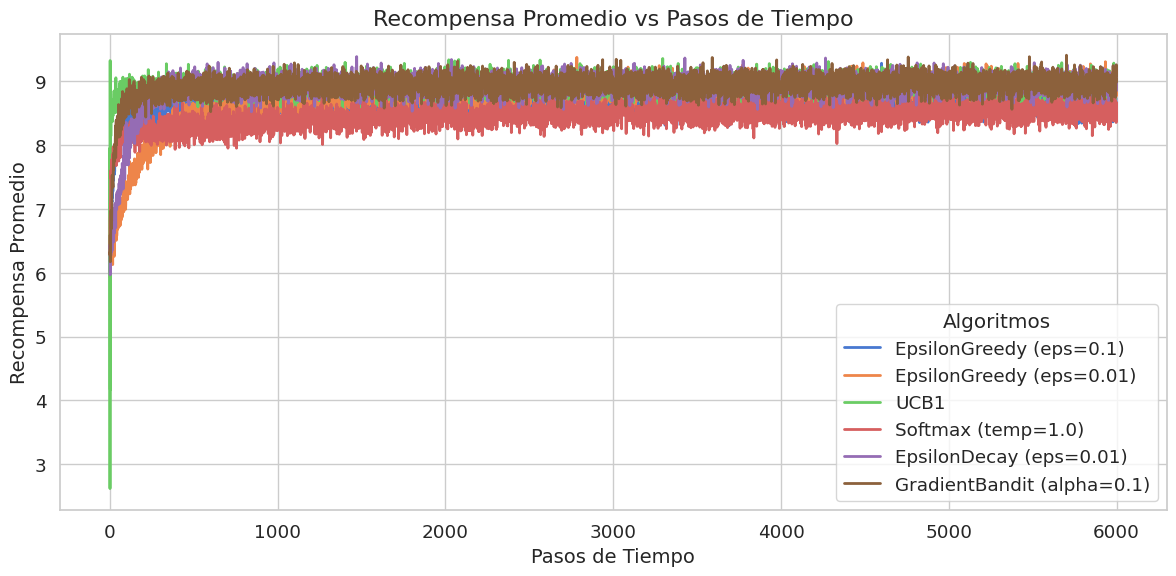

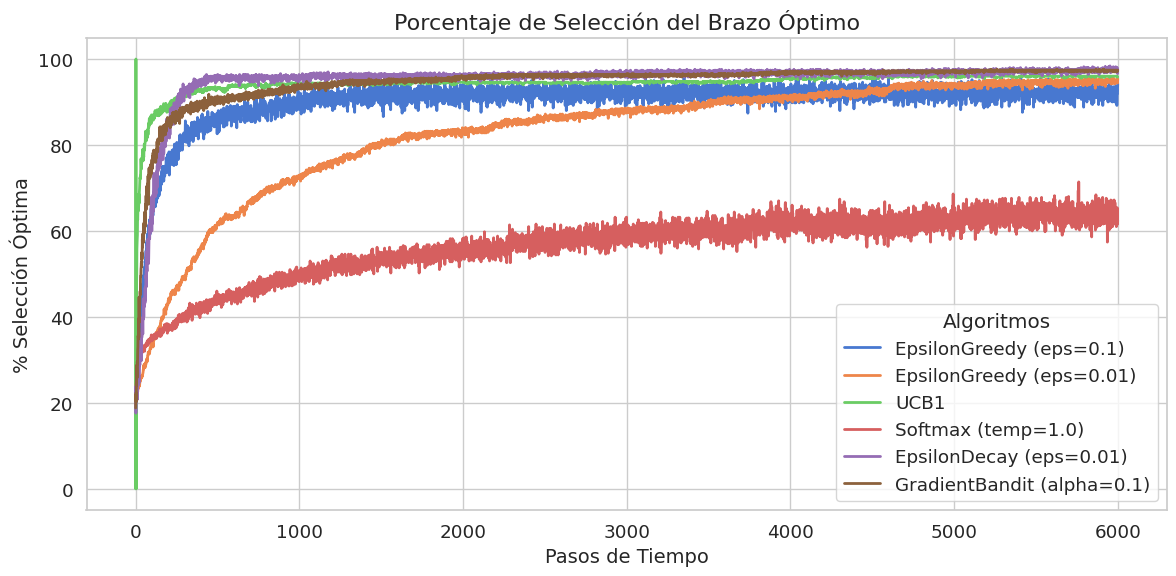

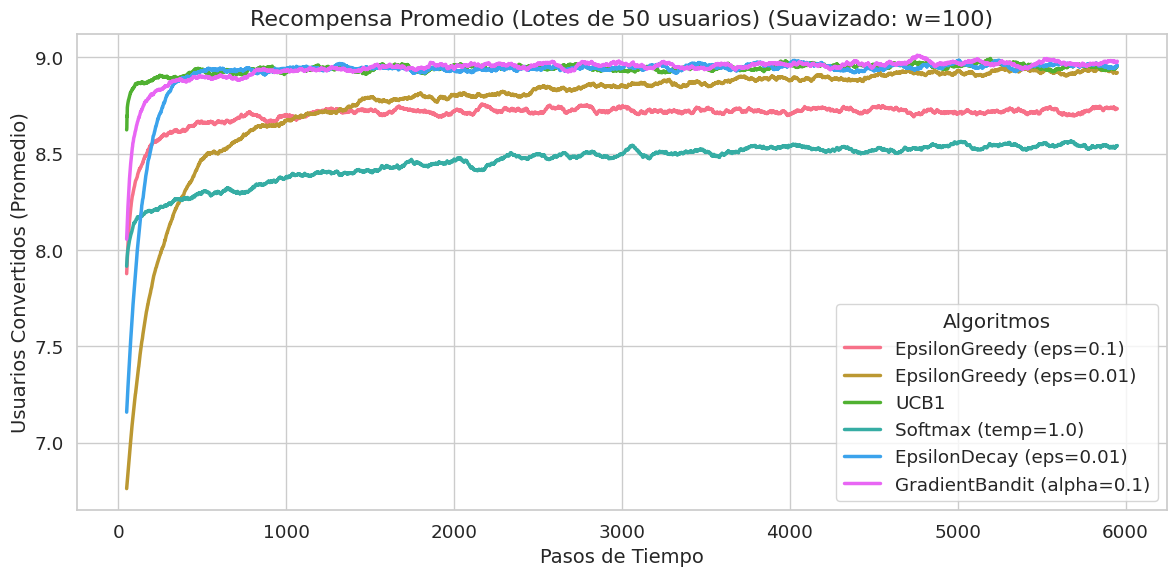

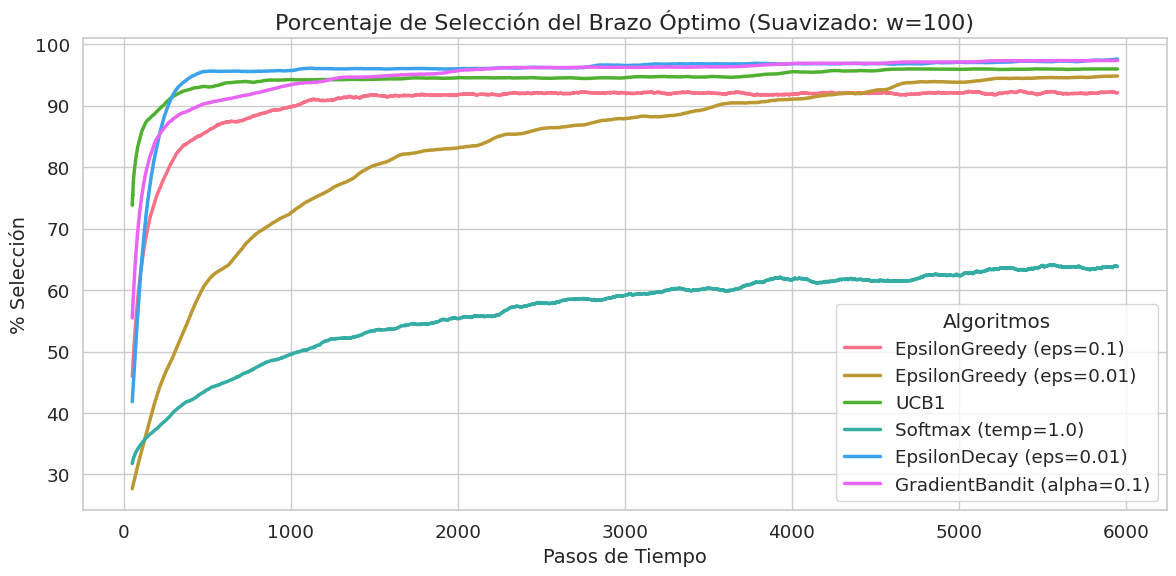

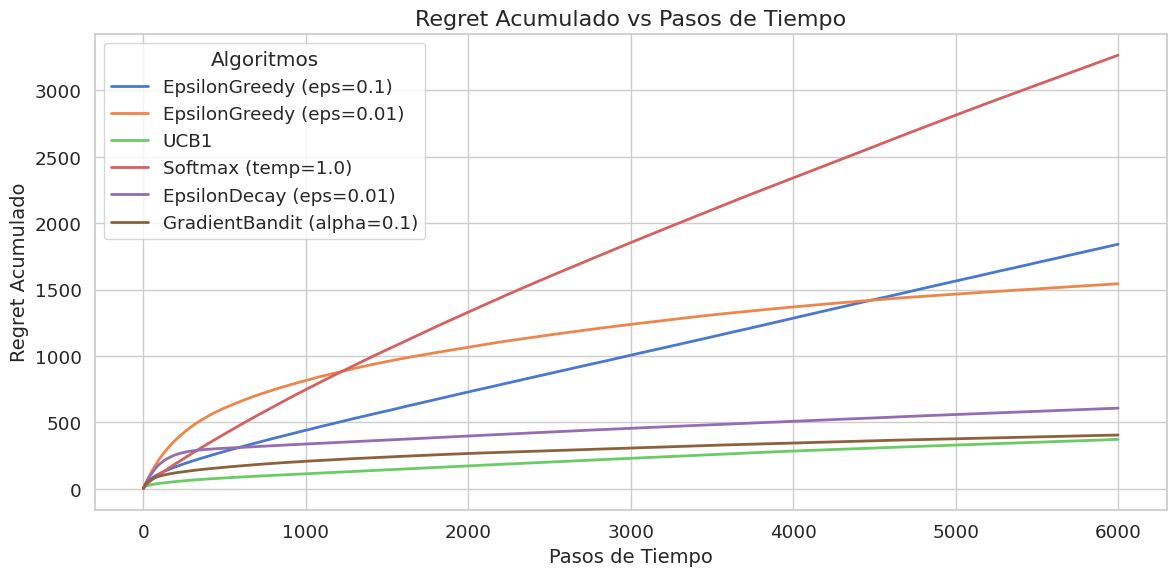

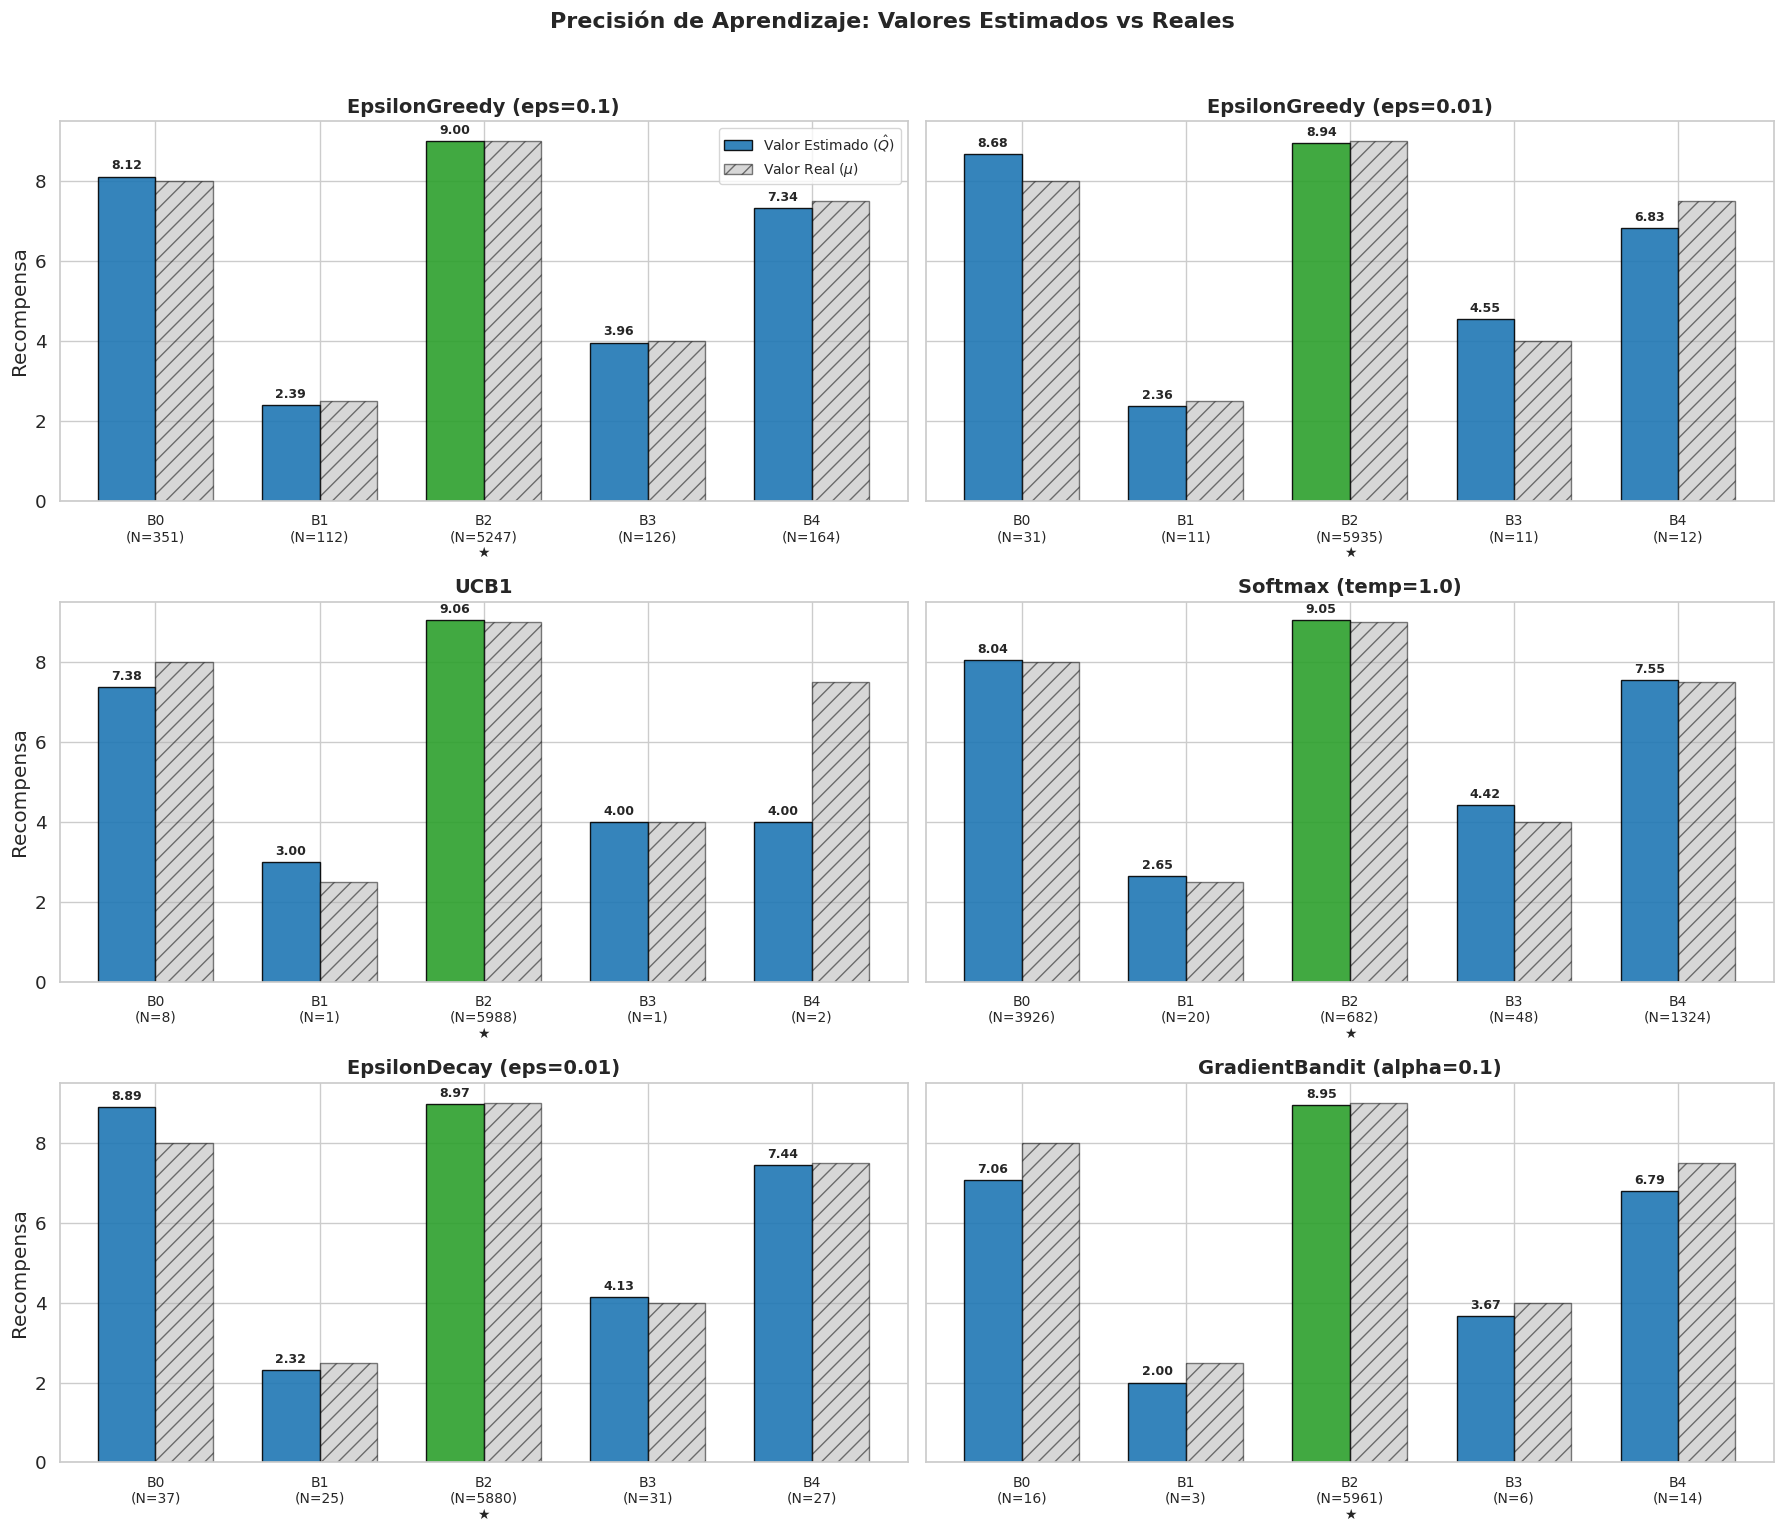

In [5]:
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_smoothed_curves

plot_average_rewards(N_STEPS, r_avg, algorithms_list)
plot_optimal_selections(N_STEPS, opt_avg, algorithms_list)
# 1. Gráfica de Recompensa Promedio (Suavizada)
# El valor óptimo es 9.0 (50 usuarios * 0.18)
plot_smoothed_curves(
    steps=N_STEPS,
    data=r_avg,
    algorithms=algorithms_list,
    title=f"Recompensa Promedio (Lotes de {BATCH_SIZE} usuarios)",
    ylabel="Usuarios Convertidos (Promedio)",
    window_size=100,
)

# 2. Selección Óptima
plot_smoothed_curves(
    steps=N_STEPS,
    data=opt_avg * 100,
    algorithms=algorithms_list,
    title="Porcentaje de Selección del Brazo Óptimo",
    ylabel="% Selección",
    window_size=100,
)

# 3. Regret Acumulado
plot_regret(N_STEPS, reg_avg, algorithms_list)

# 4. Estadísticas Finales
plot_arm_statistics(q_vals, counts, algorithms_list, optimal_arm_index=np.argmax(BANDIT_PROBS), true_means=[p * 50 for p in BANDIT_PROBS])

## 2. Análisis de Resultados: Distribución Binomial

En este escenario de **App de Delivery**, hemos introducido una complejidad adicional: la escala de la recompensa ($0$ a $50$) y su varianza asociada.

### A. Adaptación de los Algoritmos (Escala)
Un hallazgo clave es la sensibilidad extrema de **Softmax** a la escala de la recompensa.
- En el experimento de Bernoulli (recompensa 0 o 1), una temperatura $\tau=0.1$ ya resultaba problemática, produciendo una exploración insuficiente que lo relegaba a los peores niveles de selección óptima.
- En este entorno, con recompensas promedio del orden de ~9, el problema se agrava drásticamente. Usar $\tau=0.1$ causaría que $e^{9/0.1} = e^{90}$ fuera un número inmensamente grande, colapsando toda exploración. Por ello se ajustó a $\tau=1.0$, pero incluso con esta calibración los resultados son insatisfactorios: como muestran las estadísticas finales, Softmax dispersó sus selecciones de forma casi uniforme entre los brazos (asignando la mayoría de muestras al brazo sub-óptimo B0 en lugar de concentrarse en el óptimo B2), evidenciando que la temperatura aún aplasta las diferencias relativas entre valores Q cuando la escala de las recompensas es elevada.

### B. Robustez ante el Ruido (Varianza)
La **Distribución Binomial** introduce más ruido que la Bernoulli. Un brazo sub-óptimo como B0 ($p=0.16$, esperado 8) puede generar frecuentemente recompensas de 10 o 11, engañando al algoritmo para que crea que es superior al óptimo B2 ($p=0.18$, esperado 9).
- **UCB1** gestiona esta incertidumbre de forma natural: su término de exploración $c\sqrt{\frac{\ln t}{N_t(a)}}$ mantiene elevados los límites de confianza de los brazos poco muestreados, forzando su revisita hasta adquirir certeza estadística. Los resultados muestran que UCB1 converge al brazo óptimo con alta precisión ($\hat{Q} \approx 9.06$), concentrando la práctica totalidad de sus selecciones en B2 ($N=5988$) y "congelando" tempranamente las estimaciones de los brazos subóptimos.
- **Epsilon-Greedy** sufre más oscilaciones debido a este ruido, ya que su exploración uniforme no discrimina entre brazos prometedores y claramente inferiores. La variante con $\epsilon=0.01$ converge más rápido pero con mayor riesgo de estancarse en un brazo subóptimo.
- **Gradient Bandit** logra aislar el brazo óptimo eficientemente, concentrando sus selecciones en B2 ($N=5961$), gracias a su mecanismo de preferencias relativas que amplifica las diferencias entre brazos a través del gradiente estocástico.
- **Epsilon-Decay** presenta un buen equilibrio, transitando gradualmente de exploración a explotación y alcanzando una distribución de selecciones razonable ($N=5880$ en B2).

### C. Conclusión para Negocio
Para una startup de Delivery que realiza tests A/B continuos en lotes:
1.  **UCB1** es la opción más segura. Garantiza encontrar la mejor promoción sin necesidad de que un *Data Scientist* esté ajustando manualmente parámetros como $\epsilon$ o $\tau$ cada vez que cambia el tamaño del lote ($n$).
2.  Si se requiere maximizar el beneficio a muy corto plazo (pocos días de campaña), **Epsilon-Decay** agresivo puede ser superior, explotando rápidamente la promoción que parece ganadora en los primeros lotes.
3.  **Softmax debe evitarse** en este tipo de entornos sin una calibración extremadamente cuidadosa de la temperatura, ya que su sensibilidad a la escala de las recompensas lo convierte en el algoritmo menos fiable del estudio.

In [6]:
# --- Configuración del Entorno Binomial ---

# Probabilidades reales de conversión (p) para cada promoción
# El brazo 2 (índice 2) es el óptimo con p=0.18

entorno_brazos = ArmBinomial.generate_arms(k=10, n=50, p_min=0.05, p_max=0.20)
BANDIT_PROBS = [arm.p for arm in entorno_brazos]
K_ARMS = len(BANDIT_PROBS)

# Parámetro n de la Binomial (Tamaño del lote de usuarios)
BATCH_SIZE = 50

# Horizonte temporal (Número de lotes a probar)
N_STEPS = 6000

# Número de ejecuciones para promediar (Monte Carlo)
N_RUNS = 500

# Cálculo de valores esperados para referencia
# Recompensa esperada = n * p
EXPECTED_REWARDS = [p * BATCH_SIZE for p in BANDIT_PROBS]
OPTIMAL_REWARD = max(EXPECTED_REWARDS)

print("--- Configuración Delivery App ---")
print(f"Tamaño del Lote (n): {BATCH_SIZE}")
print(f"Probabilidades (p): {BANDIT_PROBS}")
print(f"Recompensas Esperadas (n*p): {EXPECTED_REWARDS}")
print(f"Mejor Brazo: Índice {np.argmax(BANDIT_PROBS)} (R={OPTIMAL_REWARD})")

# --- Selección de Algoritmos ---
# Usamos una configuración similar al experimento anterior para comparar
algorithms_list = [
    EpsilonGreedy(k=K_ARMS, epsilon=0.10),
    EpsilonGreedy(k=K_ARMS, epsilon=0.01),
    # UCB1 es "Parameter Free", se adapta solo a la escala de las recompensas
    UCB1(k=K_ARMS),
    # Softmax necesita una temperatura más alta aquí porque las recompensas son mayores (0-50)
    # Si T es muy baja (0.1), exp(50/0.1) causa overflow o determinismo prematuro.
    Softmax(k=K_ARMS, temperature=1.0),
    EpsilonDecay(k=K_ARMS, decay_rate=0.99),
    GradientBandit(k=K_ARMS, alpha=0.1)
]

results_bin = run_binomial_simulation(N_RUNS, N_STEPS, K_ARMS, BANDIT_PROBS, BATCH_SIZE, algorithms_list)
r_avg, opt_avg, reg_avg, q_vals, counts = results_bin



--- Configuración Delivery App ---
Tamaño del Lote (n): 50
Probabilidades (p): [0.1822, 0.1311, 0.1939, 0.0931, 0.0722, 0.1556, 0.1594, 0.1753, 0.0793, 0.1927]
Recompensas Esperadas (n*p): [9.11, 6.555, 9.695, 4.655, 3.61, 7.779999999999999, 7.969999999999999, 8.765, 3.965, 9.635]
Mejor Brazo: Índice 2 (R=9.695)


Simulando Lotes: 100%|██████████| 500/500 [14:43<00:00,  1.77s/it]


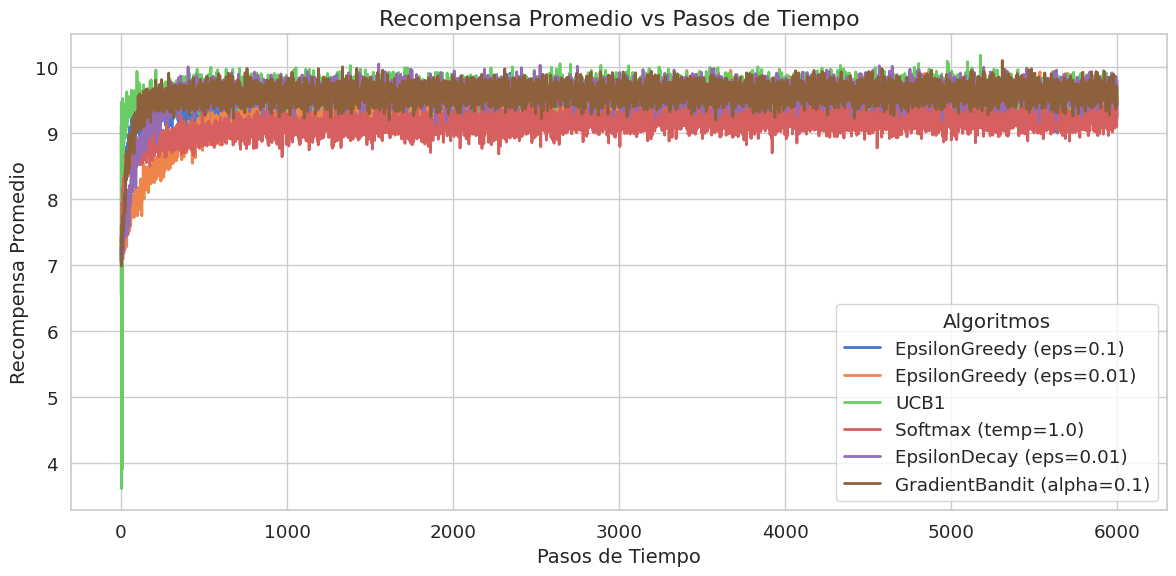

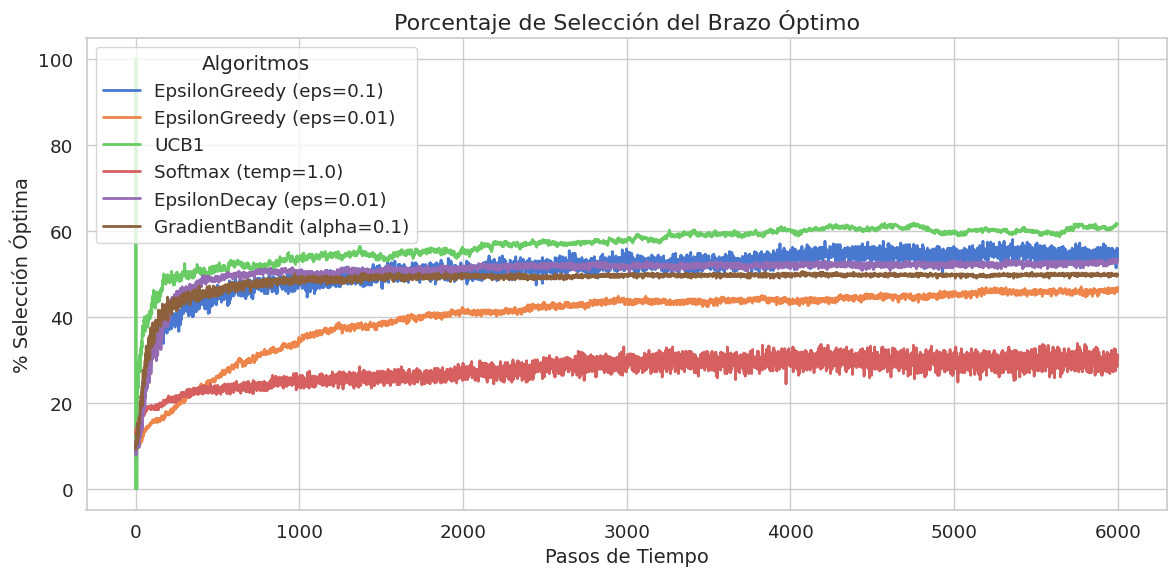

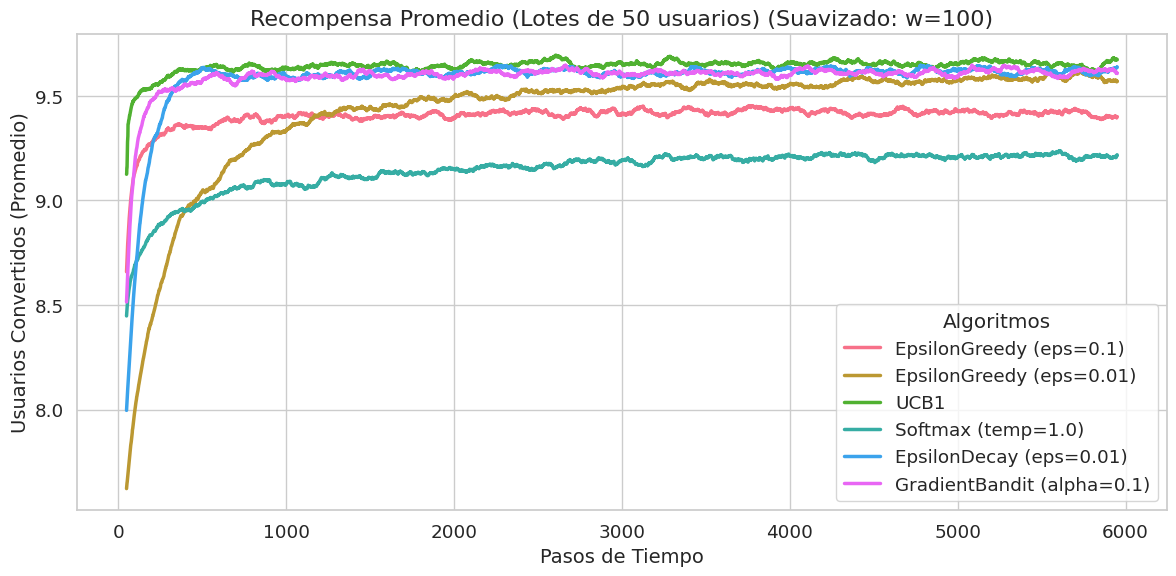

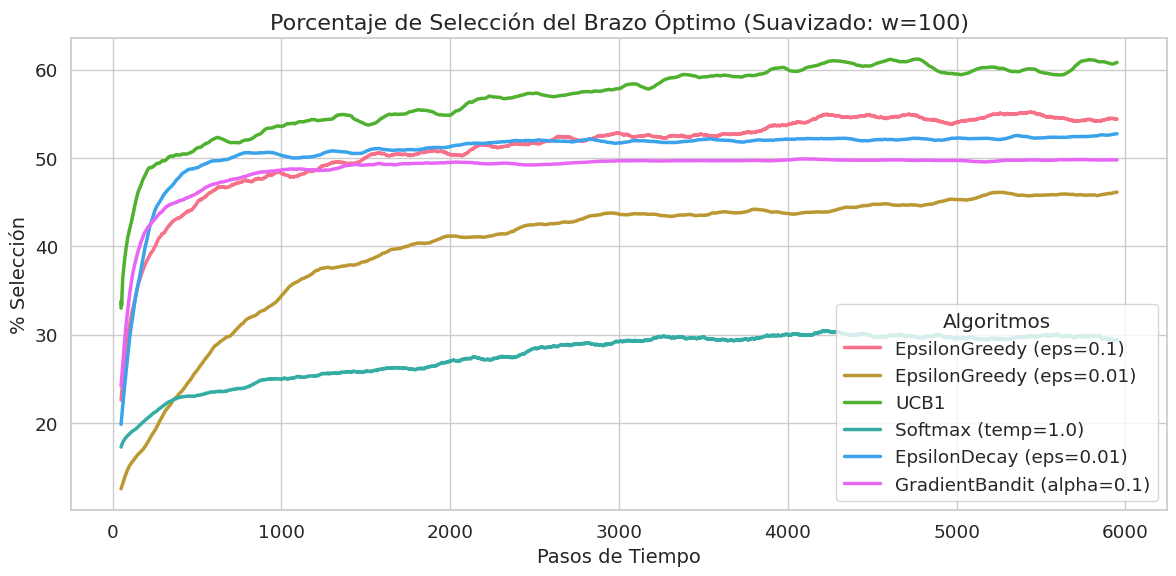

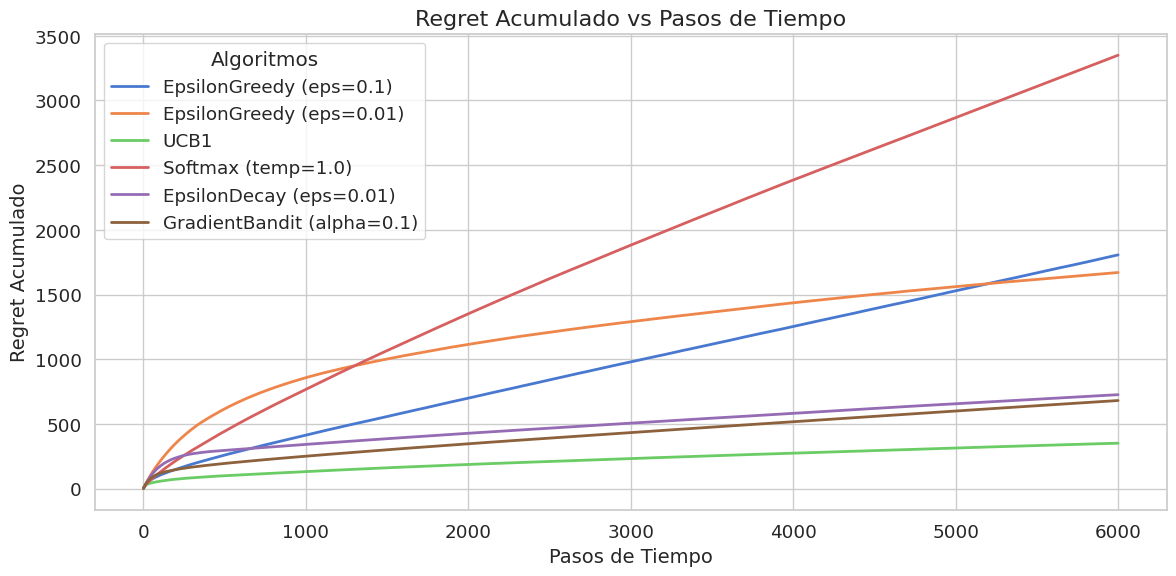

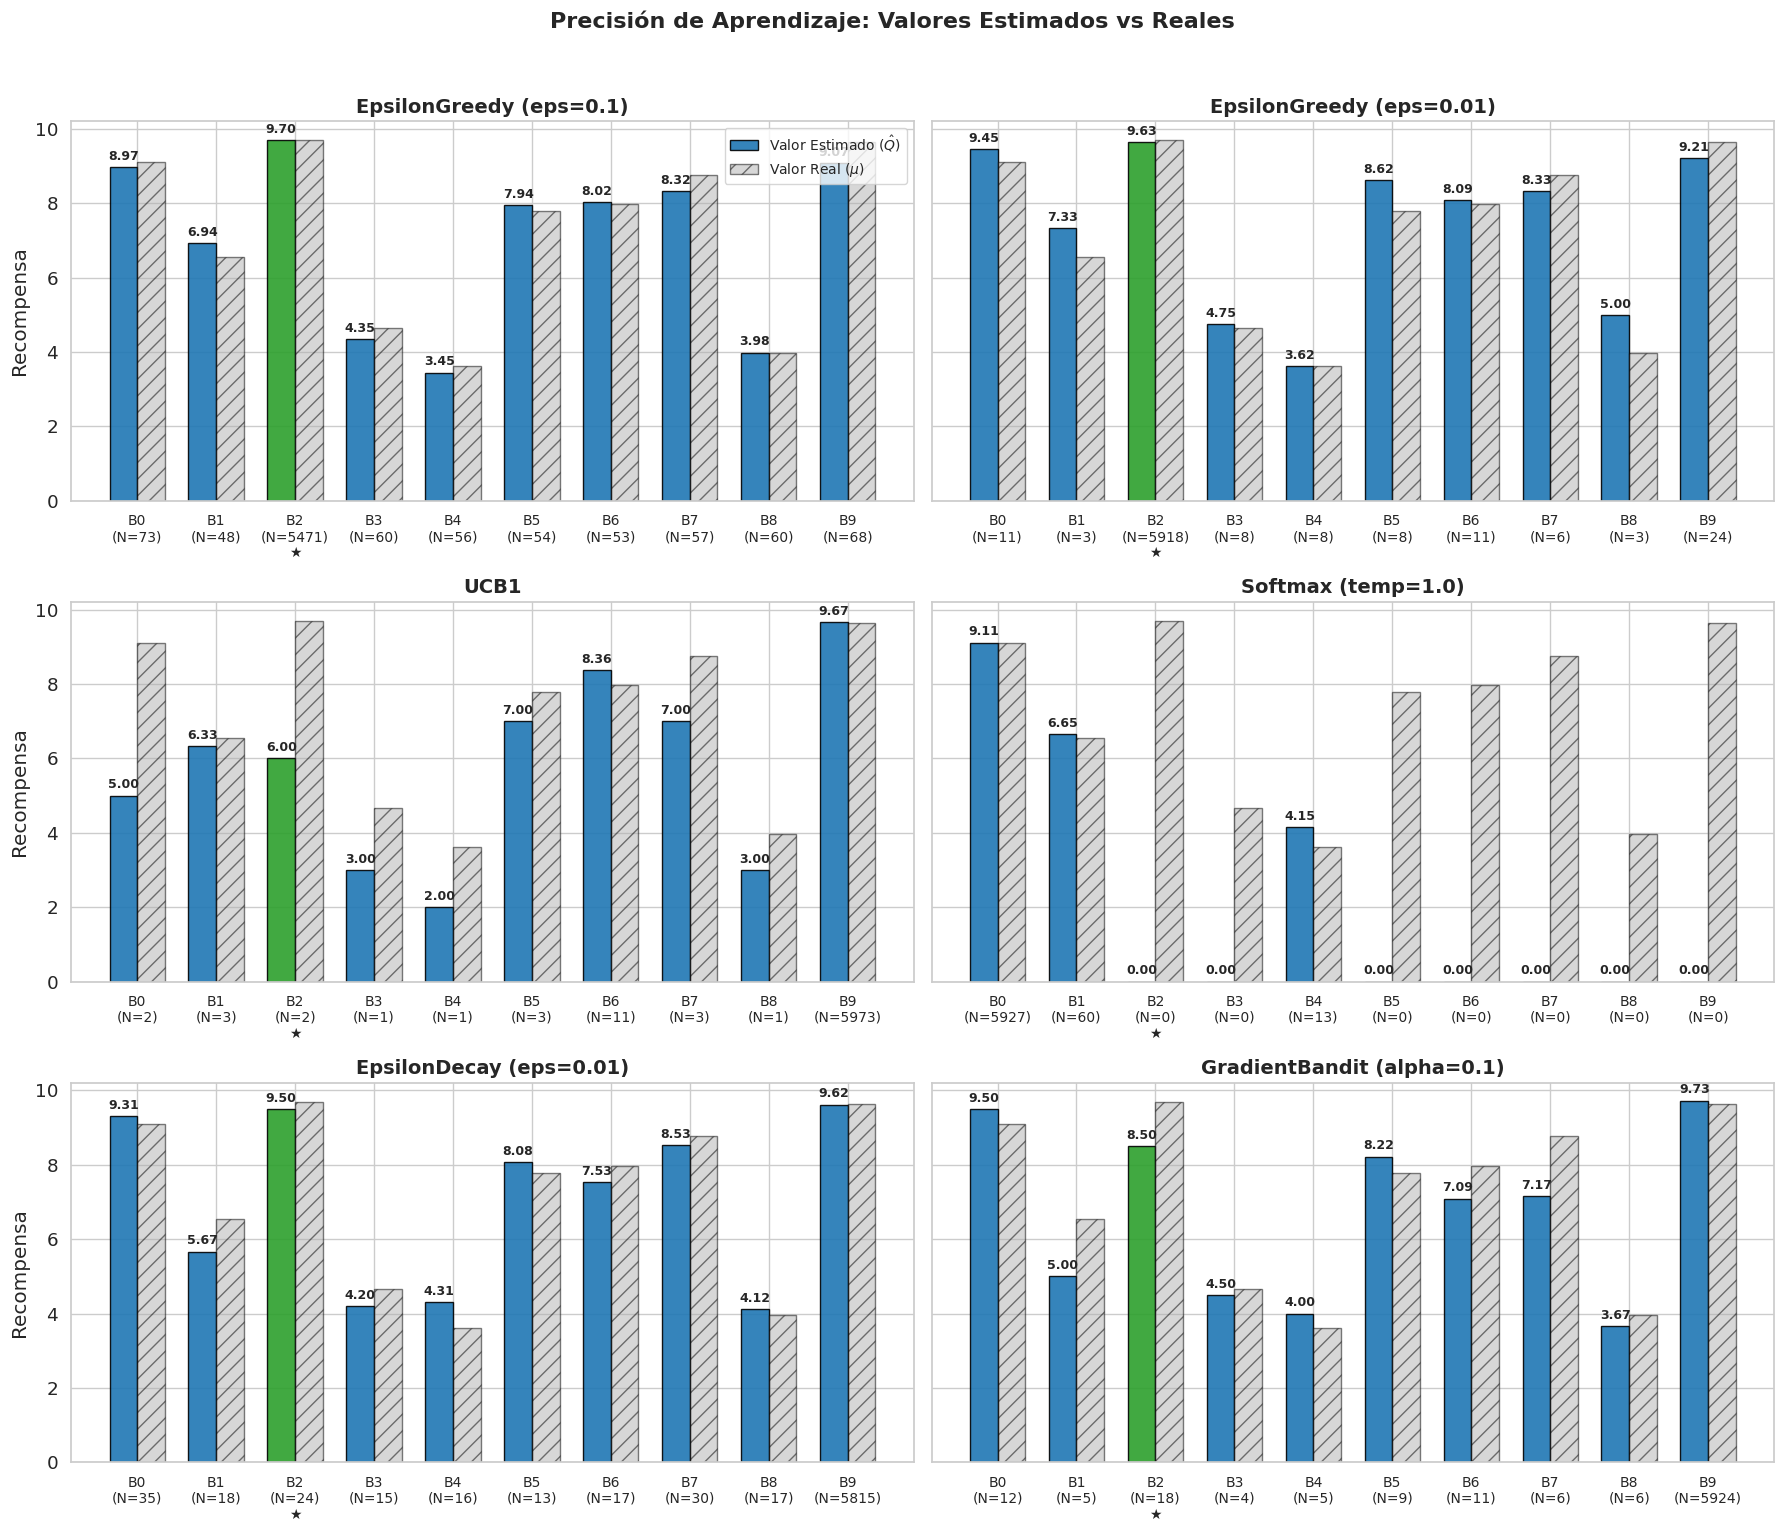

In [7]:
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_smoothed_curves

plot_average_rewards(N_STEPS, r_avg, algorithms_list)
plot_optimal_selections(N_STEPS, opt_avg, algorithms_list)
# 1. Gráfica de Recompensa Promedio (Suavizada)
# El valor óptimo es 9.0 (50 usuarios * 0.18)
plot_smoothed_curves(
    steps=N_STEPS,
    data=r_avg,
    algorithms=algorithms_list,
    title=f"Recompensa Promedio (Lotes de {BATCH_SIZE} usuarios)",
    ylabel="Usuarios Convertidos (Promedio)",
    window_size=100,
)

# 2. Selección Óptima
plot_smoothed_curves(
    steps=N_STEPS,
    data=opt_avg * 100,
    algorithms=algorithms_list,
    title="Porcentaje de Selección del Brazo Óptimo",
    ylabel="% Selección",
    window_size=100,
)

# 3. Regret Acumulado
plot_regret(N_STEPS, reg_avg, algorithms_list)

# 4. Estadísticas Finales
plot_arm_statistics(q_vals, counts, algorithms_list, optimal_arm_index=np.argmax(BANDIT_PROBS), true_means=[p * 50 for p in BANDIT_PROBS])